# Multiple Linear Regression — Demo Exercise Notebook

**Dataset:** Diabetes Dataset (sklearn built-in, no download needed)  
**Goal:** Predict disease progression score one year after baseline

---
### Table of Contents
1. Import Libraries
2. Load & Explore Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Build Multiple Linear Regression Model
6. Assumptions of Linear Regression
7. Evaluation Metrics — R2, Adjusted R2, MAE, MSE, RMSE
8. Full OLS Summary (statsmodels)
9. Final Summary


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
sns.set_style('whitegrid')
print('All libraries loaded!')


All libraries loaded!


## 2. Load & Explore Dataset

**Source:** `sklearn.datasets.load_diabetes`  
**Samples:** 442 patients  
**Target:** Quantitative measure of disease progression one year after baseline

| Feature | Description |
|---------|-------------|
| age | Age |
| sex | Sex |
| bmi | Body mass index |
| bp | Average blood pressure |
| s1-s6 | Serum measurements (cholesterol, triglycerides, blood sugar) |


In [2]:
data = load_diabetes(as_frame=True)
df   = data.frame.copy()
df.rename(columns={'target': 'ProgressionScore'}, inplace=True)
print('Dataset shape:', df.shape)
print('\nFirst 5 rows:')
df.head()


Dataset shape: (442, 11)

First 5 rows:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,ProgressionScore
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## 3. Exploratory Data Analysis (EDA)

### 3.1 Basic Statistics

In [3]:
df.describe().round(3)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,ProgressionScore
count,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000
mean,-0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,152.133
std,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,77.093
min,-0.107,-0.045,-0.090,-0.112,-0.127,-0.116,-0.102,-0.076,-0.126,-0.138,25.000
25%,-0.037,-0.045,-0.034,-0.037,-0.034,-0.030,-0.035,-0.039,-0.033,-0.033,87.000
50%,0.005,-0.045,-0.007,-0.006,-0.004,-0.004,-0.007,-0.003,-0.002,-0.001,140.500
75%,0.038,0.051,0.031,0.036,0.028,0.030,0.029,0.034,0.032,0.028,211.500
max,0.111,0.051,0.171,0.132,0.154,0.199,0.181,0.185,0.134,0.136,346.000


### 3.2 Missing Values & Data Types

In [4]:
print('Null values per column:')
print(df.isnull().sum())
print('\nData types:')
print(df.dtypes)


Null values per column:
age                 0
sex                 0
bmi                 0
bp                  0
s1                  0
s2                  0
s3                  0
s4                  0
s5                  0
s6                  0
ProgressionScore    0
dtype: int64

Data types:
age                 float64
sex                 float64
bmi                 float64
bp                  float64
s1                  float64
s2                  float64
s3                  float64
s4                  float64
s5                  float64
s6                  float64
ProgressionScore    float64
dtype: object


### 3.3 Target Variable Distribution

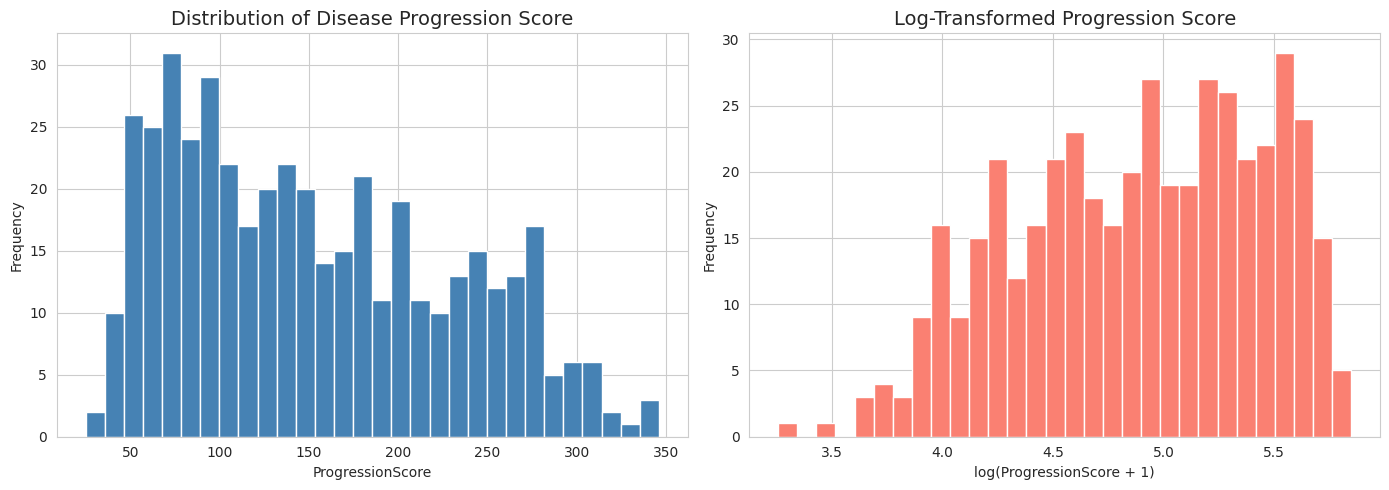

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['ProgressionScore'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Disease Progression Score')
axes[0].set_xlabel('ProgressionScore'); axes[0].set_ylabel('Frequency')
axes[1].hist(np.log1p(df['ProgressionScore']), bins=30, color='salmon', edgecolor='white')
axes[1].set_title('Log-Transformed Progression Score')
axes[1].set_xlabel('log(ProgressionScore + 1)'); axes[1].set_ylabel('Frequency')
plt.tight_layout(); plt.show()


### 3.4 Feature Distributions

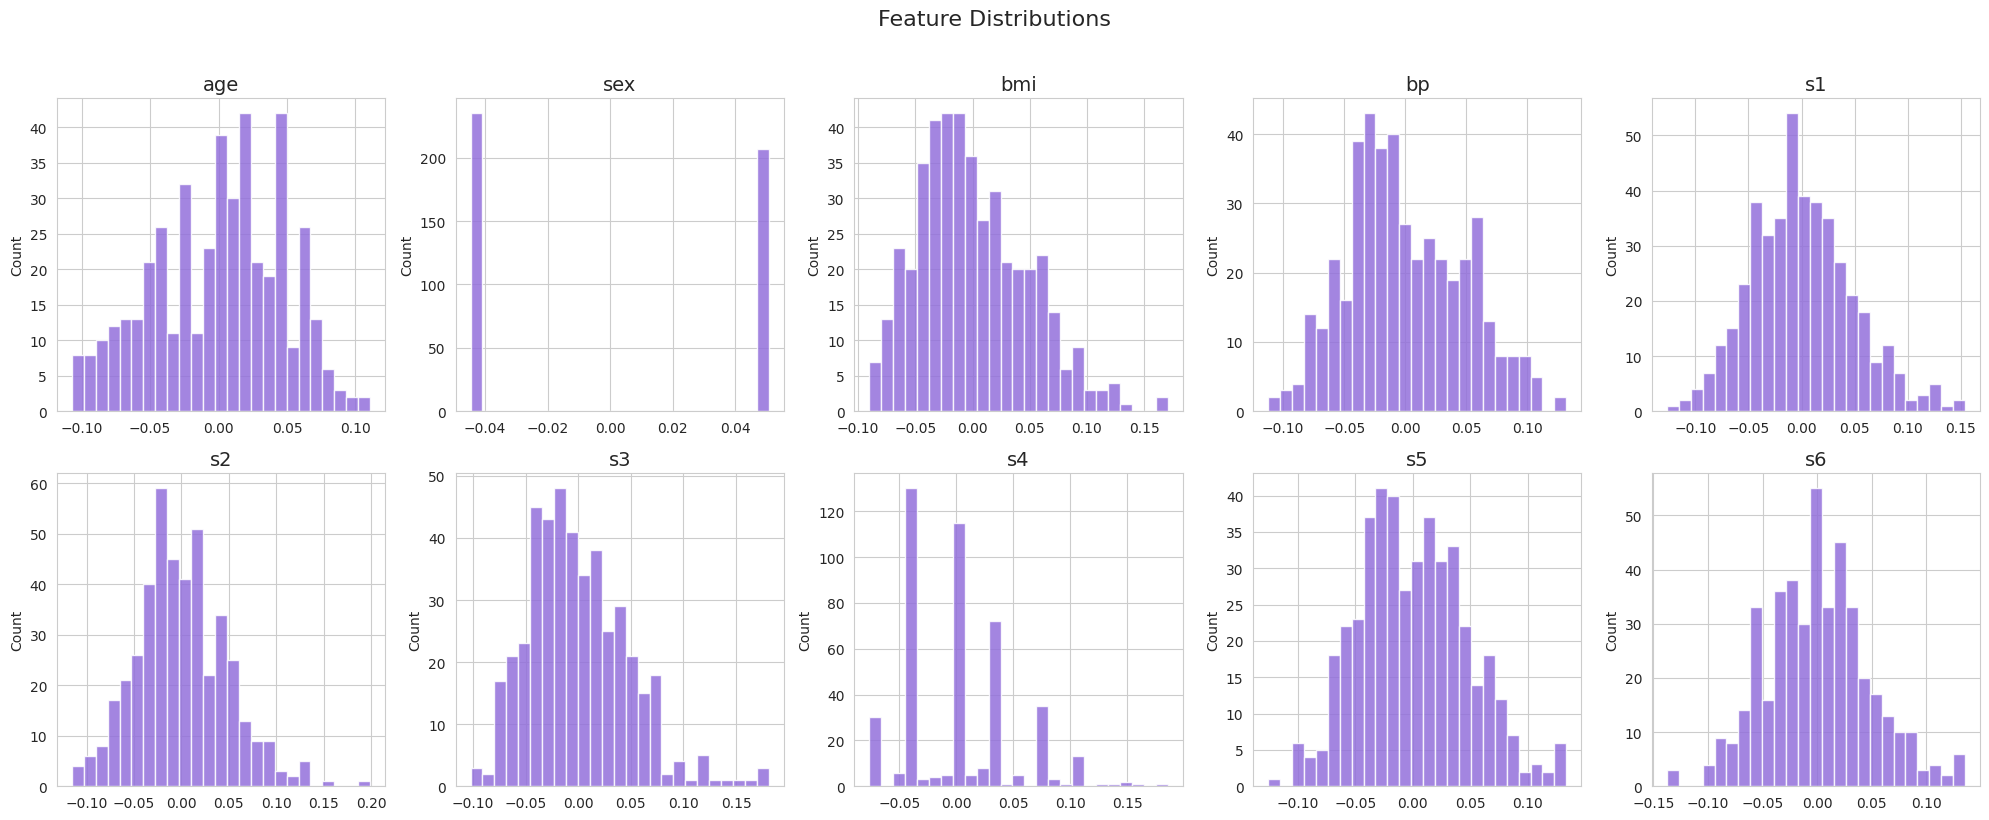

In [6]:
feature_cols = [c for c in df.columns if c != 'ProgressionScore']
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, col in enumerate(feature_cols):
    ax = axes[i // 5][i % 5]
    ax.hist(df[col], bins=25, color='mediumpurple', edgecolor='white', alpha=0.85)
    ax.set_title(col); ax.set_ylabel('Count')
plt.suptitle('Feature Distributions', fontsize=16, y=1.02)
plt.tight_layout(); plt.show()


### 3.5 Correlation Heatmap

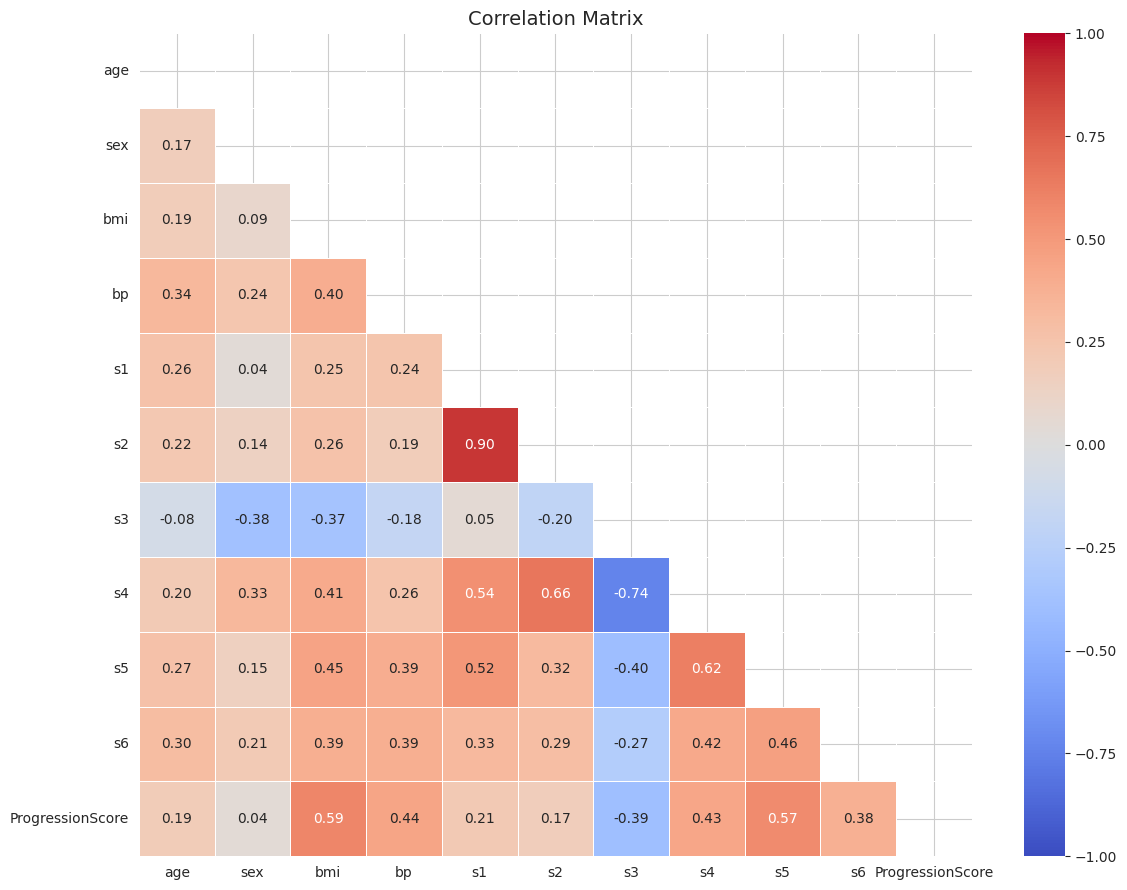


Top feature correlations with ProgressionScore:
bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
s3    -0.394789
Name: ProgressionScore, dtype: float64


In [7]:
corr = df.corr()
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix'); plt.tight_layout(); plt.show()
print('\nTop feature correlations with ProgressionScore:')
print(corr['ProgressionScore'].drop('ProgressionScore').sort_values(ascending=False))


### 3.6 Scatter Plots — Features vs Target

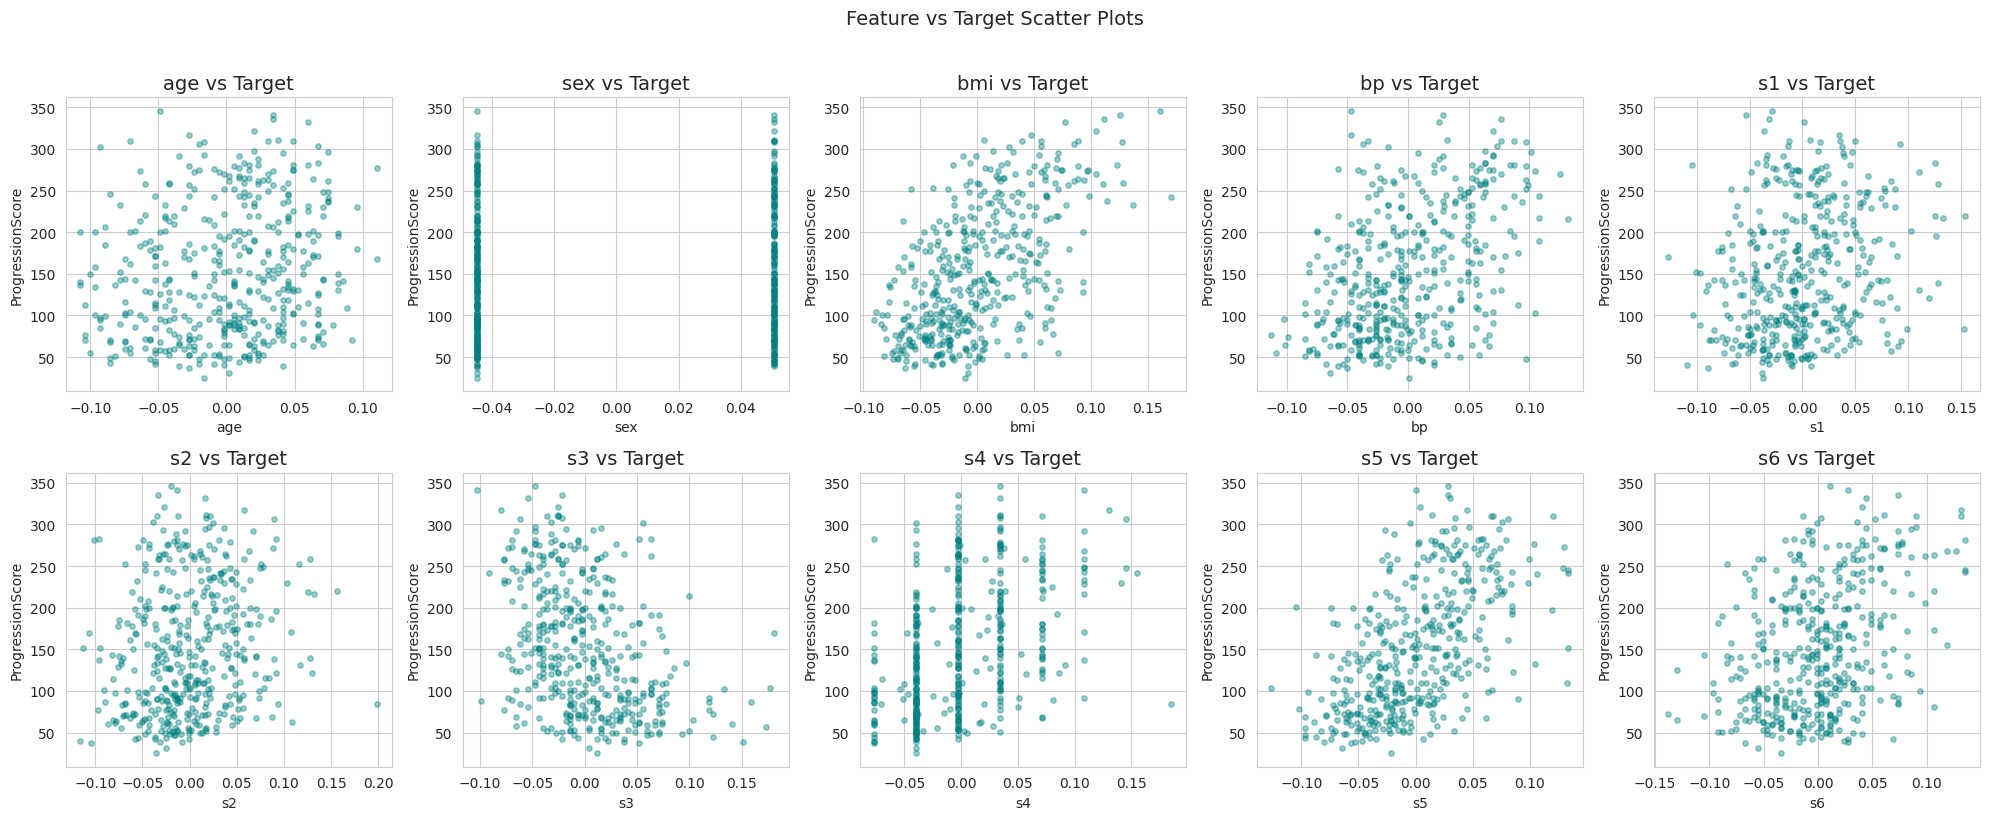

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, col in enumerate(feature_cols):
    ax = axes[i // 5][i % 5]
    ax.scatter(df[col], df['ProgressionScore'], alpha=0.4, s=15, color='teal')
    ax.set_xlabel(col); ax.set_ylabel('ProgressionScore'); ax.set_title(f'{col} vs Target')
plt.suptitle('Feature vs Target Scatter Plots', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()


## 4. Data Preprocessing

### 4.1 Train-Test Split (80/20)

In [9]:
X = df[feature_cols]
y = df['ProgressionScore']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training samples  : {X_train.shape[0]}')
print(f'Test samples      : {X_test.shape[0]}')
print(f'Number of features: {X_train.shape[1]}')


Training samples  : 353
Test samples      : 89
Number of features: 10


### 4.2 Feature Scaling (StandardScaler)

In [10]:
scaler     = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=feature_cols)
print('Scaled training data -- mean and std after scaling:')
X_train_sc.describe().round(3).loc[['mean','std']]


Scaled training data -- mean and std after scaling:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
mean,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001


## 5. Build Multiple Linear Regression Model

### 5.1 Train the Model

In [11]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': lr.coef_})
coef_df = coef_df.sort_values('Coefficient', ascending=False)
print(f'Intercept : {lr.intercept_:.4f}')
print('\nCoefficients (sorted):')
print(coef_df.to_string(index=False))


Intercept : 153.7365

Coefficients (sorted):
Feature  Coefficient
     s5    35.161195
    bmi    25.607121
     s2    24.640954
     bp    16.828872
     s4    13.138784
     s3     7.676978
     s6     2.351364
    age     1.753758
    sex   -11.511809
     s1   -44.448856


### 5.2 Coefficient Visualisation

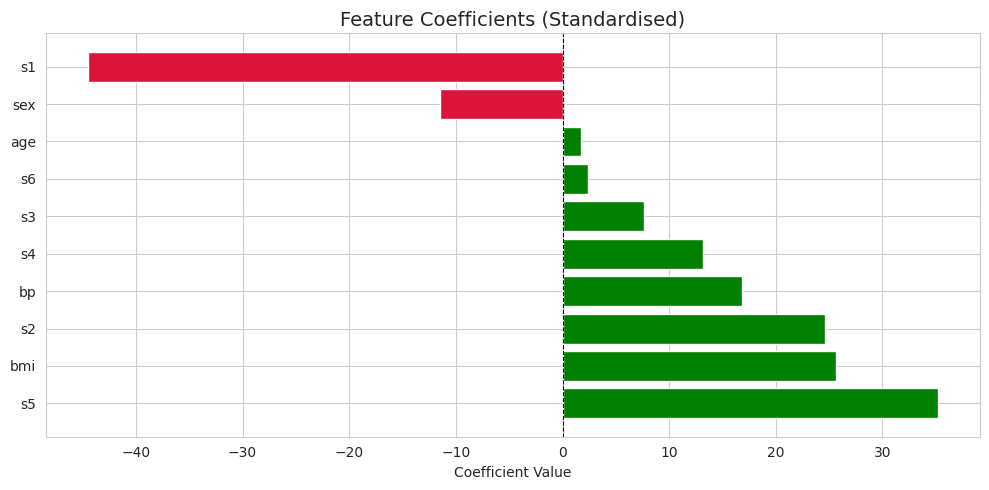

Green = increases prediction  |  Red = decreases prediction


In [12]:
colors = ['green' if c > 0 else 'crimson' for c in coef_df['Coefficient']]
plt.figure(figsize=(10, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Feature Coefficients (Standardised)')
plt.xlabel('Coefficient Value'); plt.tight_layout(); plt.show()
print('Green = increases prediction  |  Red = decreases prediction')


### 5.3 Predictions on Test Set

In [13]:
y_pred_train = lr.predict(X_train_sc)
y_pred_test  = lr.predict(X_test_sc)
preview = pd.DataFrame({
    'Actual'   : y_test.values[:10],
    'Predicted': np.round(y_pred_test[:10], 2),
    'Residual' : np.round(y_test.values[:10] - y_pred_test[:10], 2)
})
print('First 10 test set predictions:')
print(preview.to_string(index=False))


First 10 test set predictions:
 Actual  Predicted  Residual
  219.0     139.55     79.45
   70.0     179.52   -109.52
  202.0     134.04     67.96
  230.0     291.42    -61.42
  111.0     123.79    -12.79
   84.0      92.17     -8.17
  242.0     258.23    -16.23
  272.0     181.34     90.66
   94.0      90.22      3.78
   96.0     108.63    -12.63


## 6. Assumptions of Linear Regression

| # | Assumption | Diagnostic |
|---|-----------|------------|
| 1 | Linearity | Residuals vs Fitted |
| 2 | Independence | Durbin-Watson test |
| 3 | Homoscedasticity | Scale-Location plot |
| 4 | Normality of residuals | Q-Q plot + Shapiro-Wilk |
| 5 | No multicollinearity | VIF |


In [14]:
residuals     = y_test.values - y_pred_test
std_residuals = residuals / residuals.std()
print(f'Residuals  Mean : {residuals.mean():.4f}')
print(f'Residuals  Std  : {residuals.std():.4f}')


Residuals  Mean : 3.9128
Residuals  Std  : 53.7111


### 6.1 Assumption 1 — Linearity (Residuals vs Fitted)

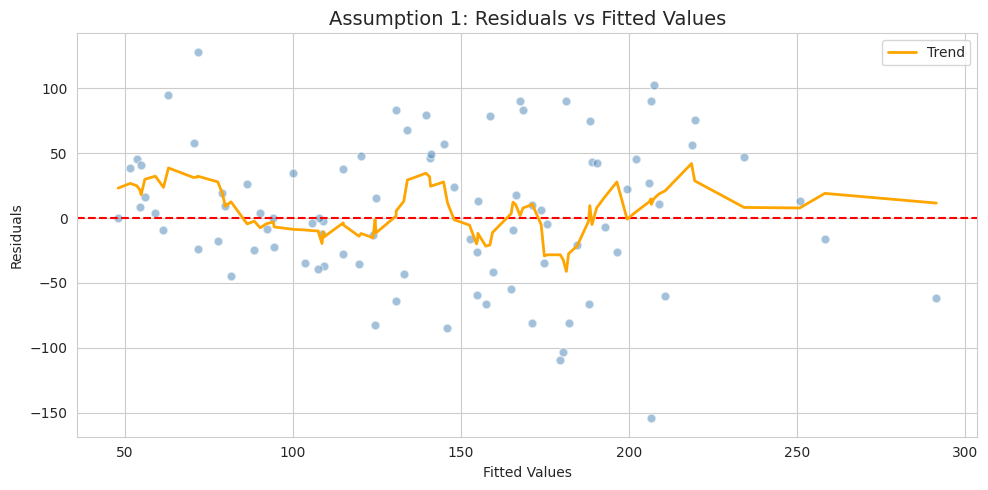


INTERPRETATION
  IDEAL   : Random scatter around y=0; flat orange trend line.
  PROBLEM : Curved trend line = non-linearity exists.
  REMEDY  : Add polynomial features or transform predictors.


In [15]:
plt.figure(figsize=(10, 5))
plt.scatter(y_pred_test, residuals, alpha=0.5, s=40, color='steelblue', edgecolors='white')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
idx = np.argsort(y_pred_test)
smoothed = pd.Series(residuals[idx]).rolling(8, center=True, min_periods=1).mean()
plt.plot(np.sort(y_pred_test), smoothed, color='orange', linewidth=2, label='Trend')
plt.xlabel('Fitted Values'); plt.ylabel('Residuals')
plt.title('Assumption 1: Residuals vs Fitted Values')
plt.legend(); plt.tight_layout(); plt.show()
print('\nINTERPRETATION')
print('  IDEAL   : Random scatter around y=0; flat orange trend line.')
print('  PROBLEM : Curved trend line = non-linearity exists.')
print('  REMEDY  : Add polynomial features or transform predictors.')


### 6.2 Assumption 2 — Independence (Durbin-Watson Test)

In [16]:
dw_stat = durbin_watson(residuals)
print(f'Durbin-Watson statistic: {dw_stat:.4f}')
print('\nINTERPRETATION')
print('  DW ~ 2.0  : No autocorrelation  (GOOD)')
print('  DW < 1.5  : Positive autocorrelation  (PROBLEM)')
print('  DW > 2.5  : Negative autocorrelation  (PROBLEM)')
print('  Acceptable range: 1.5 to 2.5')


Durbin-Watson statistic: 2.2428

INTERPRETATION
  DW ~ 2.0  : No autocorrelation  (GOOD)
  DW < 1.5  : Positive autocorrelation  (PROBLEM)
  DW > 2.5  : Negative autocorrelation  (PROBLEM)
  Acceptable range: 1.5 to 2.5


### 6.3 Assumption 3 — Homoscedasticity (Scale-Location)

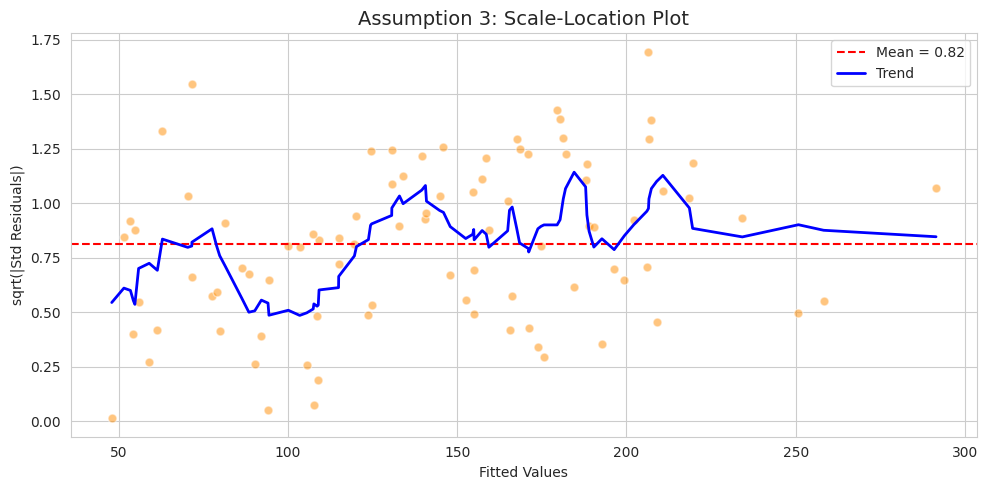


INTERPRETATION
  IDEAL   : Horizontal line; even spread across fitted values.
  PROBLEM : Funnel shape = heteroscedasticity.
  REMEDY  : Log-transform target; use WLS.


In [17]:
sqrt_std_res = np.sqrt(np.abs(std_residuals))
mean_sqrt    = sqrt_std_res.mean()
plt.figure(figsize=(10, 5))
plt.scatter(y_pred_test, sqrt_std_res, alpha=0.5, s=40, color='darkorange', edgecolors='white')
plt.axhline(mean_sqrt, color='red', linestyle='--', linewidth=1.5, label=f'Mean = {mean_sqrt:.2f}')
idx2 = np.argsort(y_pred_test)
smooth2 = pd.Series(sqrt_std_res[idx2]).rolling(8, center=True, min_periods=1).mean()
plt.plot(np.sort(y_pred_test), smooth2, color='blue', linewidth=2, label='Trend')
plt.xlabel('Fitted Values'); plt.ylabel('sqrt(|Std Residuals|)')
plt.title('Assumption 3: Scale-Location Plot')
plt.legend(); plt.tight_layout(); plt.show()
print('\nINTERPRETATION')
print('  IDEAL   : Horizontal line; even spread across fitted values.')
print('  PROBLEM : Funnel shape = heteroscedasticity.')
print('  REMEDY  : Log-transform target; use WLS.')


### 6.4 Assumption 4 — Normality of Residuals (Q-Q Plot + Shapiro-Wilk)

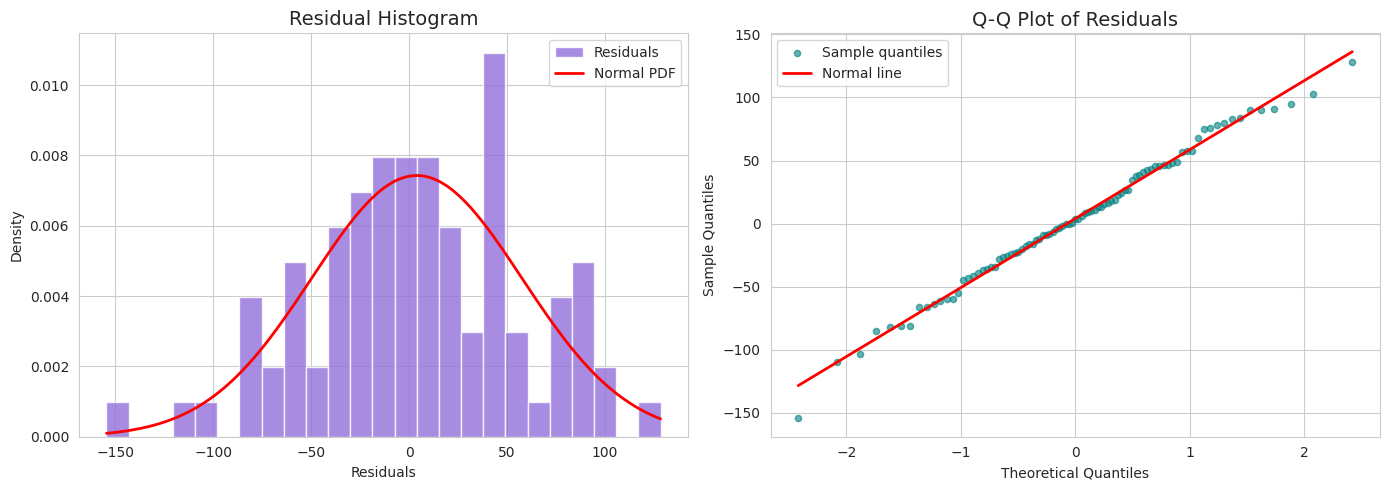

Shapiro-Wilk:  W = 0.9927,  p = 0.9066
Verdict: Cannot reject normality (p>=0.05)

INTERPRETATION
  Q-Q points on diagonal : normally distributed residuals (GOOD).
  Tails curling away      : heavy tails or skewness.
  REMEDY                  : Log or Box-Cox transform the target.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(residuals, bins=25, color='mediumpurple', edgecolor='white', density=True, alpha=0.8, label='Residuals')
xr = np.linspace(residuals.min(), residuals.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()), color='red', linewidth=2, label='Normal PDF')
axes[0].set_title('Residual Histogram'); axes[0].set_xlabel('Residuals'); axes[0].set_ylabel('Density')
axes[0].legend()
(osm, osr), (slope, intercept, r_val) = stats.probplot(residuals)
axes[1].scatter(osm, osr, alpha=0.6, s=20, color='teal', label='Sample quantiles')
axes[1].plot(osm, slope * np.array(osm) + intercept, color='red', linewidth=2, label='Normal line')
axes[1].set_title('Q-Q Plot of Residuals'); axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Sample Quantiles'); axes[1].legend()
plt.tight_layout(); plt.show()
stat, p_val = stats.shapiro(residuals)
print(f'Shapiro-Wilk:  W = {stat:.4f},  p = {p_val:.4f}')
verdict = 'Cannot reject normality (p>=0.05)' if p_val >= 0.05 else 'Reject normality (p<0.05)'
print(f'Verdict: {verdict}')
print('\nINTERPRETATION')
print('  Q-Q points on diagonal : normally distributed residuals (GOOD).')
print('  Tails curling away      : heavy tails or skewness.')
print('  REMEDY                  : Log or Box-Cox transform the target.')


### 6.5 Assumption 5 — No Multicollinearity (VIF)

In [19]:
X_vif  = sm.add_constant(X_train_sc.reset_index(drop=True))
vif_df = pd.DataFrame({
    'Feature': X_train_sc.columns,
    'VIF'    : [variance_inflation_factor(X_vif.values, i + 1)
                for i in range(X_train_sc.shape[1])]
}).sort_values('VIF', ascending=False)
def flag(v):
    if v < 5:    return 'Low (OK)'
    elif v < 10: return 'Moderate'
    else:        return 'High -- action needed'
vif_df['Status'] = vif_df['VIF'].apply(flag)
print(vif_df.to_string(index=False))
print('\nINTERPRETATION')
print('  VIF < 5    : Low multicollinearity  (Acceptable)')
print('  5-10       : Moderate              (Monitor)')
print('  VIF >= 10  : Severe               (Remove or regularise)')
print('  REMEDY     : Drop features, use PCA or Ridge Regression.')


Feature       VIF                Status
     s1 55.252137 High -- action needed
     s2 35.759309 High -- action needed
     s3 14.285594 High -- action needed
     s5 10.071155 High -- action needed
     s4  9.333044              Moderate
    bmi  1.573561              Low (OK)
     s6  1.500654              Low (OK)
     bp  1.422084              Low (OK)
    sex  1.268854              Low (OK)
    age  1.217114              Low (OK)

INTERPRETATION
  VIF < 5    : Low multicollinearity  (Acceptable)
  5-10       : Moderate              (Monitor)
  VIF >= 10  : Severe               (Remove or regularise)
  REMEDY     : Drop features, use PCA or Ridge Regression.


## 7. Evaluation Metrics

### 7.1 Compute All Metrics

In [20]:
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

n_tr, p = X_train_sc.shape
n_te    = X_test_sc.shape[0]
r2_tr = r2_score(y_train, y_pred_train)
r2_te = r2_score(y_test,  y_pred_test)

metrics_df = pd.DataFrame({
    'Metric': ['R2', 'Adjusted R2', 'MAE', 'MSE', 'RMSE'],
    'Train' : [
        r2_tr,
        adjusted_r2(r2_tr, n_tr, p),
        mean_absolute_error(y_train, y_pred_train),
        mean_squared_error(y_train,  y_pred_train),
        np.sqrt(mean_squared_error(y_train, y_pred_train))
    ],
    'Test'  : [
        r2_te,
        adjusted_r2(r2_te, n_te, p),
        mean_absolute_error(y_test, y_pred_test),
        mean_squared_error(y_test,  y_pred_test),
        np.sqrt(mean_squared_error(y_test, y_pred_test))
    ]
}).set_index('Metric').round(4)
print(metrics_df)


                 Train       Test
Metric                           
R2              0.5279     0.4526
Adjusted R2     0.5141     0.3824
MAE            43.4835    42.7941
MSE          2868.5497  2900.1936
RMSE           53.5588    53.8534


### 7.2 What Each Metric Means

| Metric | Formula | Key Points |
|--------|---------|------------|
| **R2** | 1 - SS_res/SS_tot | % variance explained. Range 0-1. Higher is better |
| **Adjusted R2** | 1-(1-R2)(n-1)/(n-p-1) | Penalises useless features. Best for model comparison |
| **MAE** | mean(abs(y-yhat)) | Average error in original units. Robust to outliers |
| **MSE** | mean((y-yhat)^2) | Squares errors — large mistakes penalised more |
| **RMSE** | sqrt(MSE) | Same units as target. Most popular error metric |

> A large Train-Test gap in R2 = **overfitting**.


### 7.3 Actual vs Predicted Plot

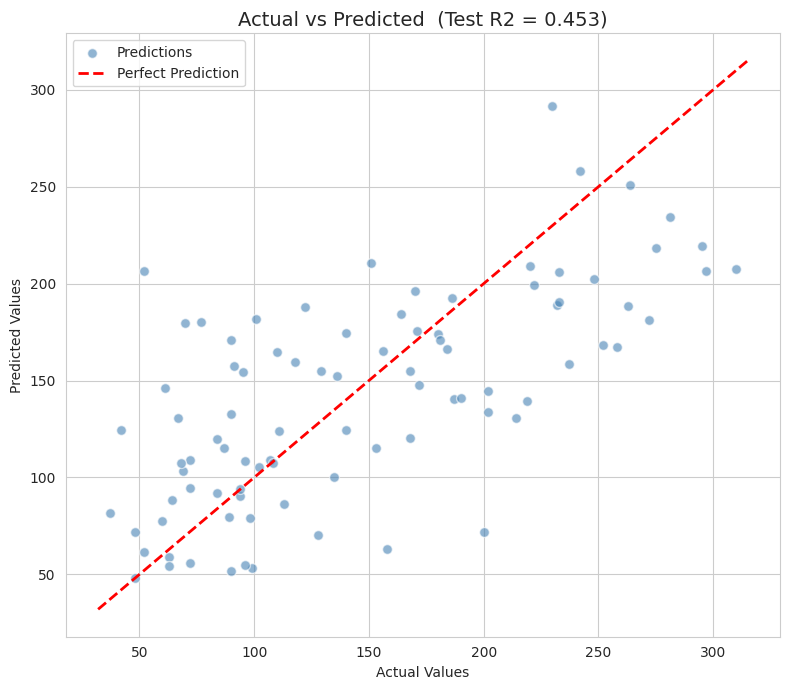

Points on the red diagonal = perfect prediction. Scatter = prediction error.


In [21]:
plt.figure(figsize=(8, 7))
plt.scatter(y_test, y_pred_test, alpha=0.6, s=50, color='steelblue', edgecolors='white', label='Predictions')
lo = min(y_test.min(), y_pred_test.min()) - 5
hi = max(y_test.max(), y_pred_test.max()) + 5
plt.plot([lo, hi], [lo, hi], color='red', linewidth=2, linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Values'); plt.ylabel('Predicted Values')
plt.title(f'Actual vs Predicted  (Test R2 = {r2_te:.3f})')
plt.legend(); plt.tight_layout(); plt.show()
print('Points on the red diagonal = perfect prediction. Scatter = prediction error.')


### 7.4 Residual Distribution

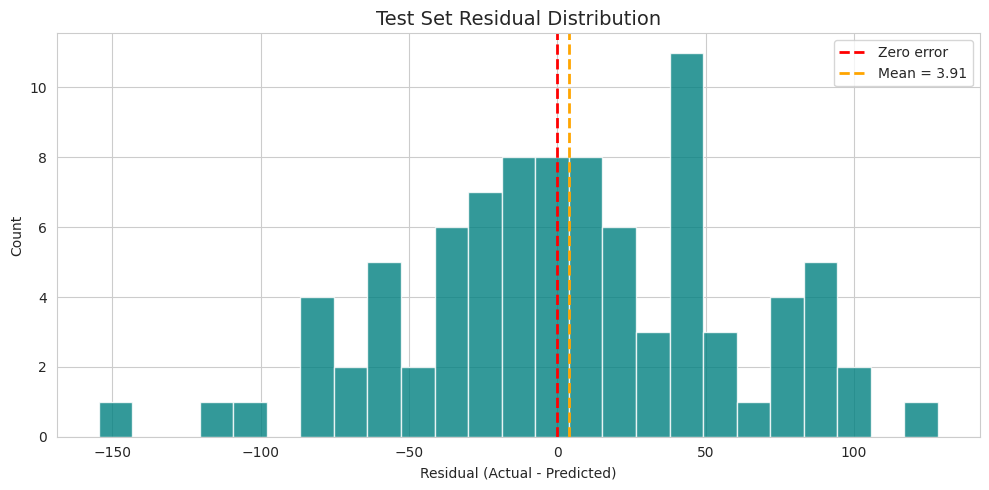

In [22]:
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=25, color='teal', edgecolor='white', alpha=0.8)
plt.axvline(0,                color='red',    linestyle='--', linewidth=2, label='Zero error')
plt.axvline(residuals.mean(), color='orange', linestyle='--', linewidth=2,
            label=f'Mean = {residuals.mean():.2f}')
plt.xlabel('Residual (Actual - Predicted)'); plt.ylabel('Count')
plt.title('Test Set Residual Distribution')
plt.legend(); plt.tight_layout(); plt.show()


## 8. Full OLS Summary (statsmodels)

In [23]:
X_sm = sm.add_constant(X_train_sc.values)
ols  = sm.OLS(y_train.values, X_sm).fit()
print(ols.summary())
print('\nHOW TO READ THE OLS SUMMARY')
print('coef    : estimated coefficient')
print('std err : standard error of estimate')
print('t       : t-statistic = coef/std err')
print('P>|t|   : p-value; < 0.05 = significant')
print('[0.025/0.975] : 95% confidence interval')
print('Adj. R2 : R2 penalised for # predictors')
print('AIC/BIC : lower = better (model comparison)')


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.528
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     38.25
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           5.41e-50
Time:                        05:48:19   Log-Likelihood:                -1906.1
No. Observations:                 353   AIC:                             3834.
Df Residuals:                     342   BIC:                             3877.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        153.7365      2.896     53.083      0.0

## 9. Final Summary

In [24]:
r2_te    = r2_score(y_test, y_pred_test)
r2_tr    = r2_score(y_train, y_pred_train)
adj_r2te = adjusted_r2(r2_te, n_te, p)
mae_te   = mean_absolute_error(y_test, y_pred_test)
mse_te   = mean_squared_error(y_test,  y_pred_test)
rmse_te  = np.sqrt(mse_te)

print('=' * 58)
print('   MULTIPLE LINEAR REGRESSION  --  FINAL SUMMARY')
print('=' * 58)
print(f'  Dataset           : Diabetes (n=442, features=10)')
print(f'  Target            : Disease Progression Score')
print()
print('  MODEL PERFORMANCE (Test Set)')
print(f'  Train R2          : {r2_tr:.4f}')
print(f'  Test  R2          : {r2_te:.4f}  ->  {r2_te*100:.1f}% variance explained')
print(f'  Adjusted R2       : {adj_r2te:.4f}')
print(f'  MAE               : {mae_te:.2f}')
print(f'  RMSE              : {rmse_te:.2f}')
print()
print('  ASSUMPTIONS CHECKED')
print('  Linearity         : Residuals vs Fitted plot')
print('  Independence      : Durbin-Watson test')
print('  Homoscedasticity  : Scale-Location plot')
print('  Normality         : Q-Q + Shapiro-Wilk')
print('  Multicollinearity : VIF table')
print()
print('  NEXT STEPS')
print('  1. Ridge / Lasso Regression')
print('  2. Polynomial features')
print('  3. Log-transform target')
print('  4. Tree-based models (RF, XGBoost)')
print('=' * 58)


   MULTIPLE LINEAR REGRESSION  --  FINAL SUMMARY
  Dataset           : Diabetes (n=442, features=10)
  Target            : Disease Progression Score

  MODEL PERFORMANCE (Test Set)
  Train R2          : 0.5279
  Test  R2          : 0.4526  ->  45.3% variance explained
  Adjusted R2       : 0.3824
  MAE               : 42.79
  RMSE              : 53.85

  ASSUMPTIONS CHECKED
  Linearity         : Residuals vs Fitted plot
  Independence      : Durbin-Watson test
  Homoscedasticity  : Scale-Location plot
  Normality         : Q-Q + Shapiro-Wilk
  Multicollinearity : VIF table

  NEXT STEPS
  1. Ridge / Lasso Regression
  2. Polynomial features
  3. Log-transform target
  4. Tree-based models (RF, XGBoost)
